In [1]:
!pip install sdv
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sdv.single_table import CTGANSynthesizer

In [3]:
loaded_synthesizer_normal = CTGANSynthesizer.load(filepath='nsl-kdd-gan-minority-pca.pkl')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sdv/_utils.py:290: SDV Version Warning: You are currently on SDV version 1.17.3 but this synthesizer was created on version 1.17.1. The latest bug fixes and features may not be available for this synthesizer. To see these enhancements, create and train a new synthesizer on this version.
  warnings.warn(message, SDVVersionWarning)


In [4]:
loaded_synthesizer_pca = CTGANSynthesizer.load(filepath='nsl-kdd-gan-minority-pca.pkl')

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator BayesianGaussianMixture from version 1.3.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sdv/_utils.py:290: SDV Version Warning: You are currently on SDV version 1.17.3 but this synthesizer was created on version 1.17.1. The latest bug fixes and features may not be available for this synthesizer. To see these enhancements, create and train a new synthesizer on this version.
  warnings.warn(message, SDVVersionWarning)


In [5]:
# Function to plot pie chart of a categorical column
def plot_pie_chart(column_name, frame):
    if column_name not in frame.columns:
        print(f"Column '{column_name}' not found in the dataset.")
        return
    column_data = frame[column_name].value_counts()
    plt.figure(figsize=(8, 8))
    plt.pie(column_data, labels=column_data.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Distribution of {column_name}')
    plt.show()

In [6]:
from sdv.sampling import Condition

# Function to generate synthetic data and append to the CSV file
def generate_and_append_synthetic_data(csv_file, label, num_rows, synthesizer):
    # Load the existing CSV file
    df = pd.read_csv(csv_file)

    # Define the condition to generate synthetic data for the specified label
    condition = Condition(num_rows=num_rows, column_values={'label': label})

    # Generate synthetic data
    synthetic_data = synthesizer.sample_from_conditions(conditions=[condition])
    # Round all numeric columns to 2 decimal places
    synthetic_data = synthetic_data.round(2)
    print("Number of synethtic rows: ", len(synthetic_data))

    # Concatenate the generated synthetic data with the original dataframe
    print("Number of rows before adding synthetic data: ", len(df))
    plot_pie_chart('label', df)
    updated_df = pd.concat([df, synthetic_data], ignore_index=True)
    print("Number of rows adding adding synthetic data: ", len(updated_df))
    plot_pie_chart('label', updated_df)

    # Overwrite the original CSV file with the updated dataframe
    updated_df.to_csv(csv_file, index=False)
    

Sampling conditions: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9450/9450 [00:04<00:00, 2361.58it/s]


Number of synethtic rows:  9450
Number of rows before adding synthetic data:  125973


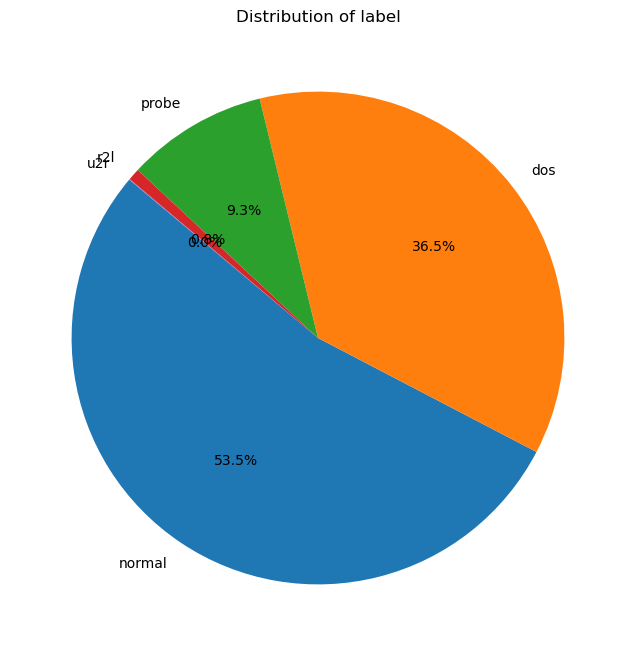

Number of rows adding adding synthetic data:  135423


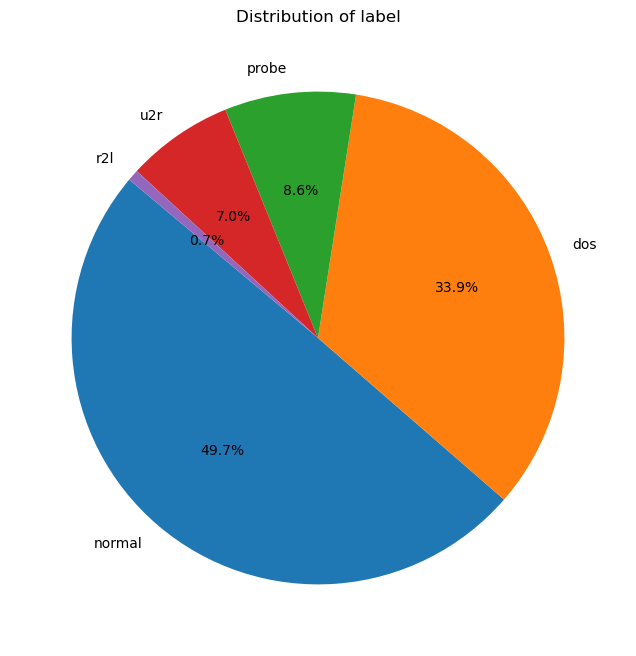

Sampling conditions: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9450/9450 [00:01<00:00, 7804.18it/s]

Number of synethtic rows:  9450
Number of rows before adding synthetic data:  135423


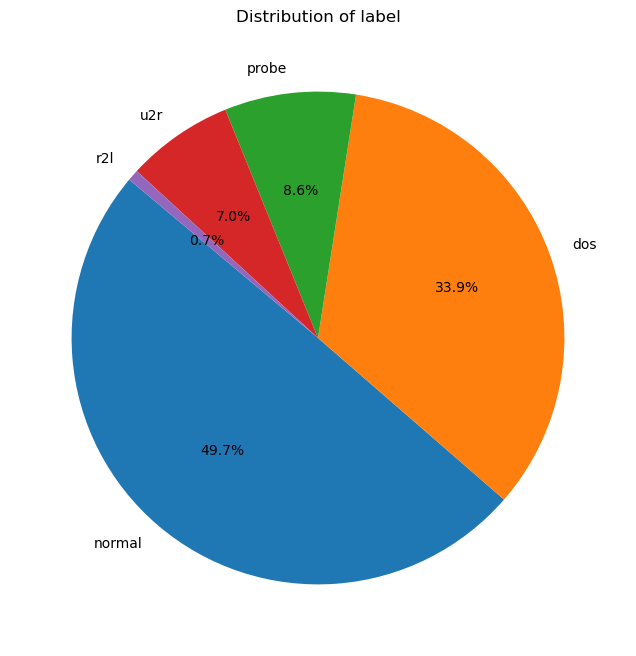

Number of rows adding adding synthetic data:  144873


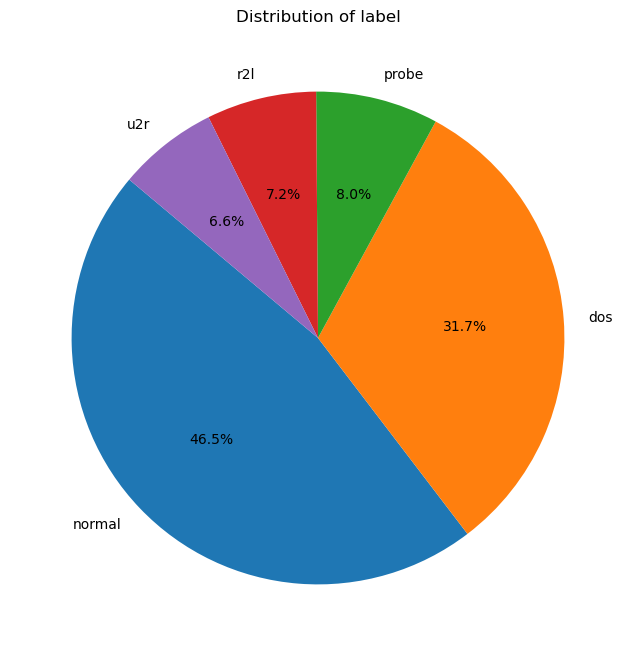

In [7]:
csv_file = 'KDDTrain.CSV'
generate_and_append_synthetic_data(csv_file, 'u2r', 9450, loaded_synthesizer_normal)
generate_and_append_synthetic_data(csv_file, 'r2l', 9450, loaded_synthesizer_normal)
#generate_and_append_synthetic_data(csv_file, 'probe', 8400, loaded_synthesizer_normal)
#generate_and_append_synthetic_data(csv_file, 'dos', 6300, loaded_synthesizer_normal)

In [8]:
## Machine Learning Models Function

In [9]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
#import tensorflow as tf
#from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from imblearn.metrics import geometric_mean_score
import joblib

In [10]:
# Function to read and display basic info of datasets
def load_data(train_path, test_path):
    data_train = pd.read_csv(train_path)
    data_test = pd.read_csv(test_path)
    return data_train, data_test

In [11]:
# Outcome mapping for the labels
outcome_mapping = {
    'normal': 0,
    'dos': 1,
    'probe': 2,
    'r2l': 3,
    'u2r': 4,
}

# Scaling function using RobustScaler
def scale_numeric_features(df_num, cols):
    std_scaler = RobustScaler()
    std_scaler_temp = std_scaler.fit_transform(df_num)
    return pd.DataFrame(std_scaler_temp, columns=cols)

# Function to preprocess the data
def preprocess(dataframe, cat_cols):
    df = dataframe.copy()
    df_num = df.drop(cat_cols, axis=1)
    num_cols = df_num.columns
    scaled_df = scale_numeric_features(df_num, num_cols)

    df.drop(labels=num_cols, axis="columns", inplace=True)
    df[num_cols] = scaled_df[num_cols]
    
    # Map label column based on the outcome_mapping
    df['label'] = df['label'].map(outcome_mapping)
    
    # One-hot encode categorical columns
    df = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'], drop_first=True)
    
    return df

In [12]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import numpy as np

def evaluate_classification(model, model_name, x_train, x_test, y_train, y_test, metrics_dict):
    """
    Evaluate a classification model using multiple metrics including sensitivity and specificity.
    
    Parameters:
    -----------
    model : sklearn classifier object
        The trained classification model
    model_name : str
        Name of the model for printing and storing results
    x_train : array-like
        Training features
    x_test : array-like
        Test features
    y_train : array-like
        Training labels
    y_test : array-like
        Test labels
    metrics_dict : dict
        Dictionary to store the evaluation metrics
        
    Returns:
    --------
    dict
        Updated metrics dictionary with new model results
    """
    # Make predictions
    y_pred = model.predict(x_test)
    
    # Calculate basic metrics
    f1 = f1_score(y_test, y_pred, average='weighted')
    accuracy = accuracy_score(y_test, y_pred)
    g_mean = geometric_mean_score(y_test, y_pred, average='weighted')
    
    # Calculate confusion matrix for each class
    cm = confusion_matrix(y_test, y_pred)
    
    # Calculate sensitivity and specificity for each class
    n_classes = len(np.unique(y_test))
    sensitivities = []
    specificities = []
    
    for i in range(n_classes):
        # True Positives, False Negatives for current class
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        
        # True Negatives, False Positives for current class
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        
        # Calculate metrics
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        sensitivities.append(sensitivity)
        specificities.append(specificity)
    
    # Average sensitivity and specificity across all classes
    avg_sensitivity = np.mean(sensitivities)
    avg_specificity = np.mean(specificities)
    
    # Print results
    print(f"\nResults for {model_name}:")
    print(f"F1 Score: {f1:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"G-mean Score: {g_mean:.4f}")
    print(f"Average Sensitivity: {avg_sensitivity:.4f}")
    print(f"Average Specificity: {avg_specificity:.4f}")

# Main Function for Running and Testing models

In [13]:
def main(cat_cols):
    # Load the data
    #data_train, data_test = load_data(train_path, test_path)
    data_train = pd.read_csv(csv_file)
    data_test = pd.read_csv('KDDTest.CSV')

    #data_train, data_test = train_test_split(data_train, test_size=0.2, random_state=42)

    #plot_pie_chart('label', data_train)
    
    # Preprocess datasets and align columns
    scaled_train = preprocess(data_train, cat_cols)
    scaled_test = preprocess(data_test, cat_cols)
    scaled_test = scaled_test.reindex(columns=scaled_train.columns, fill_value=0)
    
    print(scaled_train.size, scaled_test.size)
    scaled_train = scaled_train.dropna()
    scaled_test = scaled_test.dropna()
    print(scaled_train.size, scaled_test.size)

    # Separate features and labels
    x_train = scaled_train.drop(['label'], axis=1).values
    y_train = scaled_train['label'].values
    x_test = scaled_test.drop(['label'], axis=1).values
    y_test = scaled_test['label'].values

    # Dictionary to store evaluation metrics for each model
    kernal_evals = {}

    lr = LogisticRegression().fit(x_train, y_train)
    evaluate_classification(lr, "Logistic Regression", x_train, x_test, y_train, y_test, kernal_evals)

    knn = KNeighborsClassifier(n_neighbors=20).fit(x_train, y_train)
    evaluate_classification(knn, "KNeighborsClassifier", x_train, x_test, y_train, y_test, kernal_evals)

    # Example of using the evaluation function
    lin_svc = svm.LinearSVC().fit(x_train, y_train)
    evaluate_classification(lin_svc, "Linear SVC", x_train, x_test, y_train, y_test, kernal_evals)
    
    dt = DecisionTreeClassifier().fit(x_train, y_train)
    evaluate_classification(dt, "Decision Tree", x_train, x_test, y_train, y_test, kernal_evals)

    rf = RandomForestClassifier().fit(x_train, y_train)
    evaluate_classification(rf, "Random Forest", x_train, x_test, y_train, y_test, kernal_evals)

In [14]:
main(cat_cols = ['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login', 'label'])

17384760 2705280
15116760 2705280


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Results for Logistic Regression:
F1 Score: 0.6626
Accuracy: 0.7127
G-mean Score: 0.7641
Average Sensitivity: 0.4697
Average Specificity: 0.9064

Results for KNeighborsClassifier:
F1 Score: 0.6779
Accuracy: 0.7197
G-mean Score: 0.7620
Average Sensitivity: 0.4816
Average Specificity: 0.9053


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Results for Linear SVC:
F1 Score: 0.6177
Accuracy: 0.6298
G-mean Score: 0.7340
Average Sensitivity: 0.4127
Average Specificity: 0.8971

Results for Decision Tree:
F1 Score: 0.7287
Accuracy: 0.7528
G-mean Score: 0.8004
Average Sensitivity: 0.5371
Average Specificity: 0.9208

Results for Random Forest:
F1 Score: 0.7067
Accuracy: 0.7526
G-mean Score: 0.7904
Average Sensitivity: 0.5125
Average Specificity: 0.9166
